In [ ]:
# ============================================================
# STEP 0 - Loading the Dataset
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_sas("/Users/fatimaiqbal/Desktop/Data Mining/LLCP2023.XPT", format="xport", encoding="latin1")

##ozlem version
##df = pd.read_sas(r'C:\Users\olcer\OneDrive\Desktop\Data Mining Project\LLCP2023XPT\LLCP2023.XPT')

df.head(100)
df.shape

(433323, 350)

In [ ]:

#  2023 data

# ============================================================
# STEP 1 - Column Selection
# ============================================================
cols = ['SEQNO', '_PSU', '_STATE', 'QSTVER', 'QSTLANG', 'DIABETE4', '_RFHYPE6', 'TOLDHI3', '_CHOLCH3',
        '_BMI5', '_RFBMI5', 'SMOKE100', '_SMOKER3', 'CVDSTRK3', '_MICHD', '_TOTINDA', 
        '_RFDRHV8', '_HLTHPL1', 'MEDCOST1', 'GENHLTH', 'MENTHLTH',
        'PHYSHLTH', 'DIFFWALK', 'SEXVAR', '_AGEG5YR', 'EDUCA', 'INCOME3',
        'ADDEPEV3', 'HAVARTH4', 'CHCKDNY2']

df = df[cols]
print(f"Step 1 - After column selection: {df.shape}")

# ============================================================
# STEP 2 - Duplicate Removal
# ============================================================
before_dedup = len(df)
df = df.drop_duplicates(subset=['SEQNO', 'QSTVER', 'QSTLANG', '_STATE'])
after_dedup = len(df)
print(f"\nStep 2 - Duplicates removed: {before_dedup - after_dedup}")
print(f"After deduplication: {df.shape}")

Step 1 - After column selection: (433323, 30)

Step 2 - Duplicates removed: 0
After deduplication: (433323, 30)


In [81]:
# ============================================================
# STEP 3 - Missing Value Removal
# ============================================================
print(f"\nStep 3 - Row reduction per column:")
temp_df = df.copy()
missing_cols = df.columns[df.isnull().any()].tolist()
for col in missing_cols:
    before = len(temp_df)
    temp_df = temp_df.dropna(subset=[col])
    after = len(temp_df)
    if before - after > 0:
        print(f"  Dropping NaN in {col}: -{before - after} rows (remaining: {after})")

df = df.dropna()
print(f"\nStep 4 - Final shape after dropna: {df.shape}")


Step 3 - Row reduction per column:
  Dropping NaN in DIABETE4: -5 rows (remaining: 433318)
  Dropping NaN in TOLDHI3: -51809 rows (remaining: 381509)
  Dropping NaN in _BMI5: -33917 rows (remaining: 347592)
  Dropping NaN in SMOKE100: -5626 rows (remaining: 341966)
  Dropping NaN in CVDSTRK3: -1 rows (remaining: 341965)
  Dropping NaN in _MICHD: -3096 rows (remaining: 338869)
  Dropping NaN in GENHLTH: -1 rows (remaining: 338868)
  Dropping NaN in EDUCA: -1 rows (remaining: 338867)

Step 4 - Final shape after dropna: (338867, 30)


In [ ]:
# ============================================================
# STEP 4 -  Value Recoding and Outlier Management
# ============================================================
print("\nStep 4 - Outlier management and value recoding...")

# DIABETE4 - target variable
# 1 = Diabetic, 4 = Pre-diabetes -> keep as 1
# 2 = Pregnant only, 3 = No -> keep as 0
# 7, 9 = Don't know/Refused -> drop

df = df[~df['DIABETE4'].isin([7.0, 9.0])]  # drop unknowns first
df['DIABETE4'] = (df['DIABETE4'].isin([1.0, 4.0])).astype(int)  # 1 if diabetic, 0 otherwise

# _RFHYPE6 - high blood pressure
## Yes 1, No 2 -> Yes 1, No 0
df['_RFHYPE6'] = df['_RFHYPE6'].replace({1:0, 2:1})
df = df[df['_RFHYPE6'] != 9]

# TOLDHI3 - told high cholesterol
## No, 2 -> No, 0
df['TOLDHI3'] = df['TOLDHI3'].replace({2:0})
df = df[~df['TOLDHI3'].isin([7, 9])]

# _CHOLCH3 - cholesterol check
#Did not have cholesterol check 2, had never had cholesterol check 3 -> No 0
df['_CHOLCH3'] = df['_CHOLCH3'].replace({2:0, 3:0})
df = df[df['_CHOLCH3'] != 9]

# _BMI5 - BMI (divide by 100)
df['_BMI5'] = df['_BMI5'].div(100).round(0)

# _RFBMI5 - overweight/obese flag
## 12 < BMI <25,1 --> No,0
## BMI >= 25,2 --> Yes,1
df['_RFBMI5'] = df['_RFBMI5'].replace({1:0, 2:1})
df = df[df['_RFBMI5'] != 9]

# SMOKE100 - smoked 100 
# Smoked 100 cigarettes in lifetime: No, 2 -> No, 0
df['SMOKE100'] = df['SMOKE100'].replace({2:0})
df = df[~df['SMOKE100'].isin([7, 9])]

# _SMOKER3 - smoker status (keep ordinal 1-4)
#Current Smoker - smokes everyday, 1 
#Current Smoker - smokes some days, 2
#Former Smoker, 3
#Never Smoker, 4
df = df[df['_SMOKER3'] != 9]

# CVDSTRK3 - ever had stroke
# No, 2 -> No, 0
df['CVDSTRK3'] = df['CVDSTRK3'].replace({2:0})
df = df[~df['CVDSTRK3'].isin([7, 9])]

# _MICHD - coronary heart disease
# No, 2 -> No, 0
df['_MICHD'] = df['_MICHD'].replace({2:0})

# _TOTINDA - physical activity
# No, 2 -> No, 0
df['_TOTINDA'] = df['_TOTINDA'].replace({2:0})
df = df[df['_TOTINDA'] != 9]

# _RFDRHV8 - heavy drinker
# No,1 -> No,0
# Yes,2 -> Yes,1
df['_RFDRHV8'] = df['_RFDRHV8'].replace({1:0, 2:1})
df = df[df['_RFDRHV8'] != 9]

# _HLTHPL1 - health insurance
# No, 2 -> No, 0
df['_HLTHPL1'] = df['_HLTHPL1'].replace({2:0})
df = df[df['_HLTHPL1'] != 9]

# MEDCOST1 - could not see doctor due to cost
# No, 2 -> No, 0
df['MEDCOST1'] = df['MEDCOST1'].replace({2:0})
df = df[~df['MEDCOST1'].isin([7, 9])]

# GENHLTH - general health (keep ordinal 1-5)
# 1 Good to 5 Poor, 7 Don't know, 9 Refused
df = df[~df['GENHLTH'].isin([7, 9])]

# MENTHLTH - days mental health not good
# 88 None, 77 Don't know, 99 Refused
df['MENTHLTH'] = df['MENTHLTH'].replace({88:0})
df = df[~df['MENTHLTH'].isin([77, 99])]

# PHYSHLTH - days physical health not good
# 88 None, 77 Don't know, 99 Refused
df['PHYSHLTH'] = df['PHYSHLTH'].replace({88:0})
df = df[~df['PHYSHLTH'].isin([77, 99])]

# DIFFWALK - difficulty walking
# No, 2 -> No, 0  
df['DIFFWALK'] = df['DIFFWALK'].replace({2:0})
df = df[~df['DIFFWALK'].isin([7, 9])]

# SEXVAR - sex (1=Male, 2=Female)
# Female, 2 -> Female, 0
df['SEXVAR'] = df['SEXVAR'].replace({2:0})

# _AGEG5YR - age group (keep ordinal 1-13)
df = df[df['_AGEG5YR'] != 14]

# EDUCA - education (keep ordinal 1-6)
df = df[df['EDUCA'] != 9]

# INCOME3 - income (keep ordinal 1-11)
df = df[~df['INCOME3'].isin([77, 99])]

# ADDEPEV3 - depression
# No, 2 -> No, 0
df['ADDEPEV3'] = df['ADDEPEV3'].replace({2:0})
df = df[~df['ADDEPEV3'].isin([7, 9])]

# HAVARTH4 - arthritis
# No, 2 -> No, 0
df['HAVARTH4'] = df['HAVARTH4'].replace({2:0})
df = df[~df['HAVARTH4'].isin([7, 9])]

# CHCKDNY2 - kidney disease
# No, 2 -> No, 0
df['CHCKDNY2'] = df['CHCKDNY2'].replace({2:0})
df = df[~df['CHCKDNY2'].isin([7, 9])]


# ============================================================
# STEP 4.5 - Establishing proxies for risk groups and diseases
# ============================================================
 

# 1. Metabolic Syndrome (MetS) Proxy
# Condition: Has the three other of the four syntoms of a metabolic syndrome (diabetis is the forth syndrome)
    
is_obese = df['_BMI5'] >= 30
has_htn = df['_RFHYPE6'] == 1
has_chol = df['TOLDHI3'] == 1
    
mets_score = is_obese.astype(int) + has_htn.astype(int) + has_chol.astype(int) 
    
# Set flag to 1 if score = 3, otherwise 0
df['Metabolic_Syndrome_Flag'] = np.where(mets_score = 3, 1, 0)


# 2. High Cardiovascular Risk (ASCVD) Proxy
 # Condition: History of heart attack/stroke OR dangerous combinations
    
hist_cvd = (df['_MICHD'] == 1) | (df['CVDSTRK3'] == 1)
    
# 1 (Everyday) and 2 (Some days) represent current smokers
is_current_smoker = df['_SMOKER3'].isin([1, 2])
    
htn_chol_smoke = (df['_RFHYPE6'] == 1) & (df['TOLDHI3'] == 1) & is_current_smoker
    
 # If any conditions are met
high_risk_condition = hist_cvd | htn_chol_smoke
df['High_CVD_Risk_Profile'] = high_risk_condition.astype(int)

   
# 3. Chronic Comorbidity Burden (CCI Proxy)
# Sum of the binary indicators of the 4 major organ diseases, excluding diabetis 
    
comorbidity_cols = [ 
        '_MICHD', 
        'CVDSTRK3', 
        'CHCKDNY2'
    ]
    
df['Comorbidity_Count'] = df[comorbidity_cols].sum(axis=1)
    
# Severity
conditions = [
        df['Comorbidity_Count'] == 0,
        df['Comorbidity_Count'] == 1,
        df['Comorbidity_Count'] >= 2
    ]
choices = ['None', 'Mild', 'Severe']
df['Comorbidity_Level'] = np.select(conditions, choices, default=np.nan)

 
# 4. Behavioral Risk / Healthy Lifestyle Score (AHA Proxy)
# Starts at 0, +1 for each positive factor
    
score_smoke = df['_SMOKER3'].isin([3, 4]).astype(int)
score_active = (df['_TOTINDA'] == 1).astype(int)
score_bmi = (df['_RFBMI5'] == 0).astype(int)
score_drink = (df['_RFDRHV8'] == 0).astype(int)
    
df['Healthy_Lifestyle_Score'] = score_smoke + score_active + score_bmi + score_drink

print(f"After outlier management and recoding: {df.shape}")


Step 5 - Outlier management and value recoding...
After outlier management and recoding: (259269, 30)


In [ ]:
# ============================================================
# STEP 5 - Rename Columns
# ============================================================
df= df.rename(columns={
    'SEQNO': 'SequenceNo',
    '_PSU': 'PSU',
    '_STATE': 'State',
    'QSTVER': 'QuestionnaireVersion',
    'QSTLANG': 'QuestionnaireLang',
    'DIABETE4': 'Diabetes',
    '_RFHYPE6': 'HighBP',
    'TOLDHI3': 'HighChol',
    '_CHOLCH3': 'CholCheck',
    '_BMI5': 'BMI',
    '_RFBMI5': 'Overweight',
    'SMOKE100': 'Smoker',
    '_SMOKER3': 'SmokerStatus',
    'CVDSTRK3': 'Stroke',
    '_MICHD': 'HeartDisease',
    '_TOTINDA': 'PhysActivity',
    '_RFDRHV8': 'HeavyAlcohol',
    '_HLTHPL1': 'HealthInsurance',
    'MEDCOST1': 'NoDocCost',
    'GENHLTH': 'GenHealth',
    'MENTHLTH': 'MentHealth',
    'PHYSHLTH': 'PhysHealth',
    'DIFFWALK': 'DiffWalking',
    'SEXVAR': 'Sex',
    '_AGEG5YR': 'AgeGroup',
    'EDUCA': 'Education',
    'INCOME3': 'Income',
    'ADDEPEV3': 'Depression',
    'HAVARTH4': 'Arthritis',
    'CHCKDNY2': 'KidneyDisease'
})

print(f"\nStep 5 - After renaming columns: {df.shape}")


Step 6 - After renaming columns: (259269, 30)


Diabetes
0    215014
1     44255
Name: count, dtype: int64
Diabetes
0    82.93
1    17.07
Name: proportion, dtype: float64


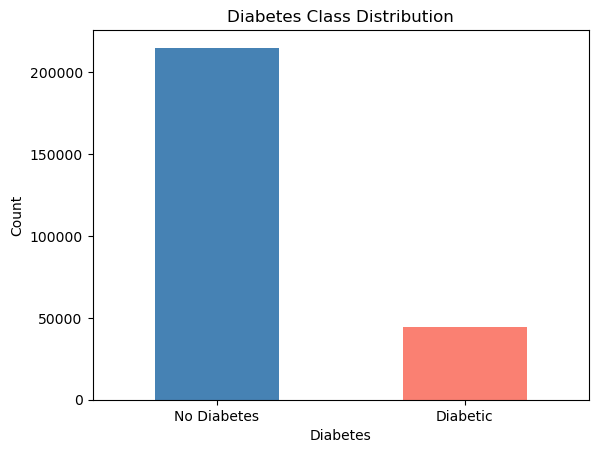

In [ ]:
# ============================================================
# STEP 6 - EDA
# ============================================================


# 1. Target variable distribution
print(df['Diabetes'].value_counts())
print(df['Diabetes'].value_counts(normalize=True).mul(100).round(2))

# 2. Class imbalance plot
df['Diabetes'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Diabetes Class Distribution')
plt.xticks([0,1], ['No Diabetes',  'Diabetic'], rotation=0)
plt.ylabel('Count')
plt.show()



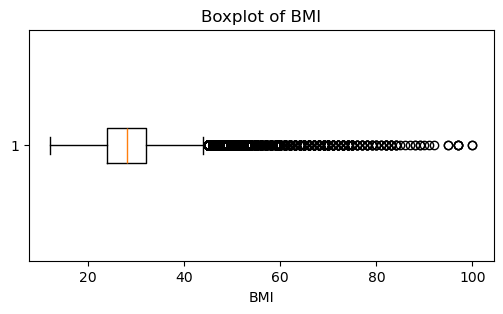

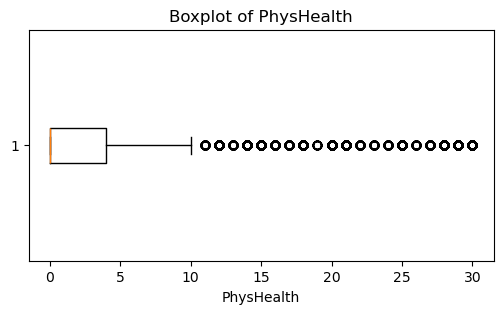

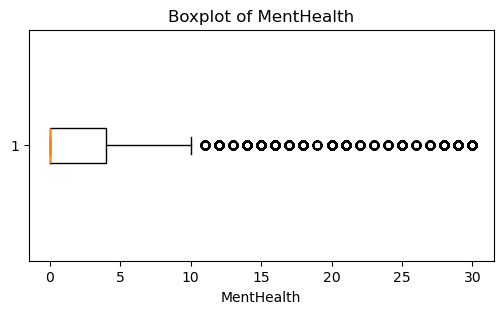

In [85]:
# ============================================================
# STEP 7 - Boxplots for numeric variables
# ============================================================
cols_for_boxplot = ["BMI", "PhysHealth", "MentHealth"]  # keep only the useful numeric ones

for col in cols_for_boxplot:
    plt.figure(figsize=(6, 3))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

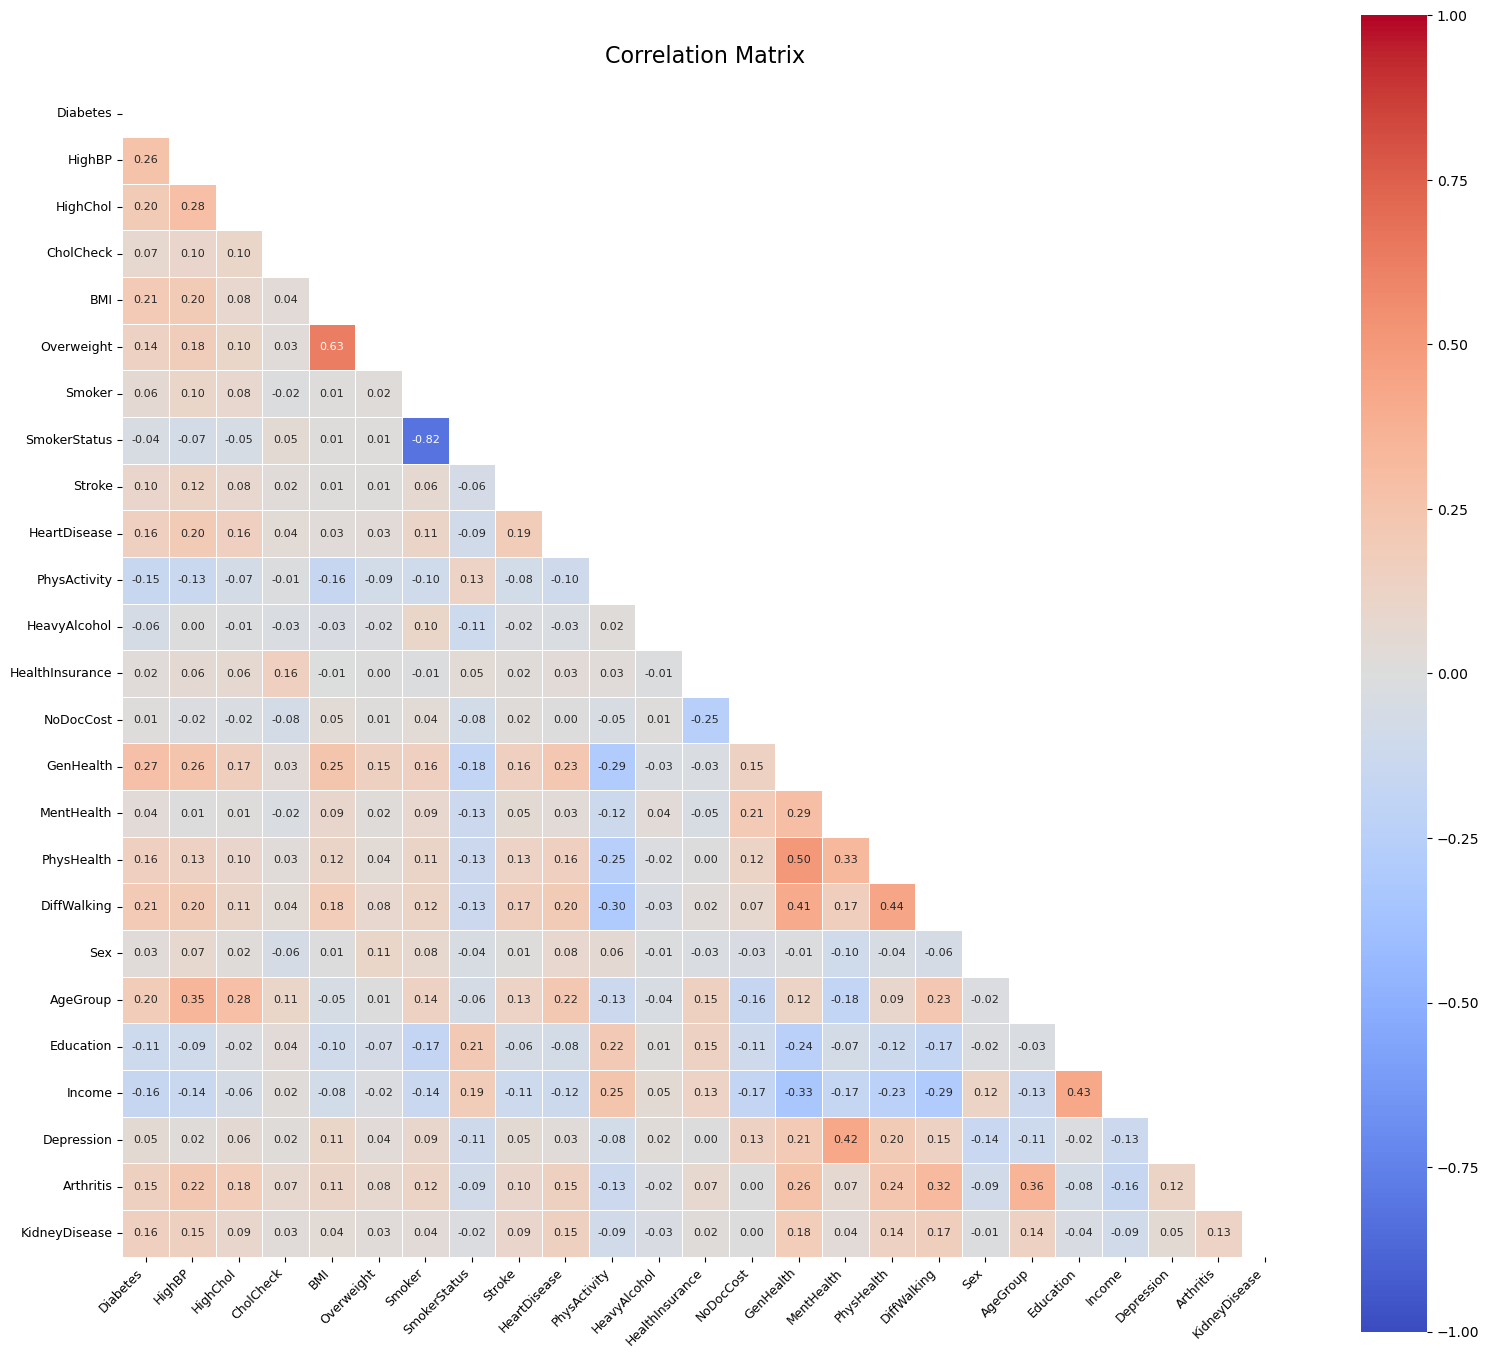

In [ ]:
# ============================================================
# STEP 8 - Correlation Check
# ============================================================
#  Drop metadata columns - not needed for analysis
cols_to_drop = ['SequenceNo', 'PSU', 'State', 'QuestionnaireVersion', 'QuestionnaireLang']
df_analysis = df.drop(columns=cols_to_drop)

# Correlation matrix - cleaner version
plt.figure(figsize=(16, 14))

corr = df_analysis.corr()

# Mask upper triangle to avoid redundancy
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    annot_kws={'size': 8},
    linewidths=0.5,
    square=True,
    vmin=-1,
    vmax=1
)

plt.title('Correlation Matrix', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

In [87]:
# ============================================================
# STEP 9 - Normalization/Standardization
# ============================================================
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Only these need scaling - binary and ordinal vars don't need it
continuous_cols = ['BMI', 'MentHealth', 'PhysHealth']
ordinal_cols = ['GenHealth', 'AgeGroup', 'Education', 'Income', 'SmokerStatus']
binary_cols = ['Diabetes', 'HighBP', 'HighChol', 'Smoker', 'Stroke',
               'HeartDisease', 'PhysActivity', 'HeavyAlcohol',
               'HealthInsurance', 'NoDocCost', 'DiffWalking', 'Sex',
               'Depression', 'Arthritis', 'KidneyDisease']

# Apply MinMaxScaler to continuous only
scaler = MinMaxScaler()
df[continuous_cols] = scaler.fit_transform(df[continuous_cols])


In [88]:
#============================================================
# SAVE FINAL FILE
# ============================================================
df.to_csv('/Users/fatimaiqbal/Desktop/Data Mining/cleaned_data_2023_final.csv', index=False)

# Ozlem version
# df.to_csv(r'C:\Users\olcer\OneDrive\Desktop\Data Mining Project\cleaned_data_2023_final.csv', index=False)
print(f"\nFinal dataset shape: {df.shape}")
print("File saved successfully!")


Final dataset shape: (259269, 30)
File saved successfully!
